# Waffle Charts, Word Clouds, Regression Plots, Treemaps và Pivot Charts
## Lab 02 - 523H0164

**Dataset:** Dữ liệu Laptop ASUS từ Cellphones

## Mục tiêu
* Tạo Waffle Charts để trực quan hóa tỷ lệ phần trăm
* Tạo Word Clouds từ dữ liệu text
* Tạo Regression Plots với thư viện Seaborn
* Tạo Treemaps để hiển thị dữ liệu phân cấp
* Tạo Pivot Charts để phân tích dữ liệu động

## Import thư viện

Chúng ta sẽ sử dụng các thư viện sau:
- **matplotlib**: Trực quan hóa dữ liệu
- **pandas & numpy**: Xử lý và phân tích dữ liệu  
- **seaborn**: Trực quan hóa thống kê nâng cao
- **wordcloud**: Tạo word clouds
- **plotly**: Tạo treemaps tương tác

In [131]:
# Cài đặt các thư viện cần thiết (nếu chưa có)
# !pip install matplotlib pandas numpy seaborn wordcloud plotly nbformat kaleido

# Import matplotlib
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches  # Cần cho Waffle Charts

mpl.style.use('ggplot')  # Style tùy chọn

# Import các module chính
import numpy as np
import pandas as pd
import re

# Import seaborn và wordcloud
import seaborn as sns
from wordcloud import WordCloud

# Import nbformat trước (cần cho Plotly treemap)
try:
    import nbformat
    print('✅ nbformat version:', nbformat.__version__)
except ImportError:
    print('⚠️ nbformat chưa được cài đặt. Chạy: pip install nbformat')

# Import plotly cho treemaps
import plotly.express as px
import plotly.io as pio
import plotly

# Cấu hình renderer cho Plotly trong Jupyter
pio.renderers.default = 'plotly_mimetype+notebook'

# Kiểm tra phiên bản
print('Matplotlib version:', mpl.__version__)
print('Seaborn version:', sns.__version__)
print('NumPy version:', np.__version__)
print('Pandas version:', pd.__version__)
print('Plotly version:', plotly.__version__)

✅ nbformat version: 5.10.4
Matplotlib version: 3.10.6
Seaborn version: 0.13.2
NumPy version: 2.2.6
Pandas version: 2.3.3
Plotly version: 6.5.0


## Đọc và Tiền xử lý Dữ liệu

Đọc dữ liệu laptop ASUS và thực hiện các bước tiền xử lý cơ bản.

In [132]:
# Đọc dữ liệu
df_laptop = pd.read_csv('laptops_asus_data_cellphones_full_v2.csv')

print('Dữ liệu laptop ASUS đã được đọc thành công!')
print(f'Kích thước dataset: {df_laptop.shape}')
print(f'\nCác cột trong dataset:')
print(df_laptop.columns.tolist())

Dữ liệu laptop ASUS đã được đọc thành công!
Kích thước dataset: (790, 12)

Các cột trong dataset:
['Name', 'Price', 'CPU', 'RAM', 'GPU', 'Storage', 'Screen Size', 'Screen Resolution', 'Panel', 'Screen frequency', 'Weight', 'URL']


In [133]:
df_laptop.head()

,Name,Price,CPU,RAM,GPU,Storage,Screen Size,Screen Resolution,Panel,Screen frequency,Weight,URL
0,Laptop ASUS TUF Gaming F16 FX607VJ-RL034W,20.990.000đ,"Intel Core 5 210H 2.2 GHz (12MB Cache, up to 4...",16GB,NVIDIA GeForce RTX 3050 6GB GDDR6Intel Iris Xe...,512GB PCIe 4.0 NVMe M.2 SSD (2 Khe cắm M.2 hỗ ...,16 inches,1920 x 1200 pixels (WUXGA),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-tuf-gami...
1,Laptop ASUS VivoBook Go 14 E1404FA-NK177W,11.490.000đ,"AMD Ryzen 5 7520U (4MB cache, up to 4.3 GHz, 4...",16GB,AMD Radeon Graphics,SSD 512GB M.2 NVMe PCIe 3.0,14 inches,1920 x 1080 pixels (FullHD),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-vivobook...
2,Laptop ASUS Gaming Vivobook 16X K3605VC-RP431W,17.990.000đ,"Intel Core i5-13420H 2.1 GHz (12MB Cache, up t...",16GB,NVIDIA Geforce RTX 3050 4GB GDDR6 Intel UHD Gr...,512GB M.2 NVMe PCIe 4.0 SSD,16 inches,1920 x 1200 pixels (WUXGA),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-vivobook...
3,Laptop ASUS Gaming V16 V3607VU-RP343W,23.990.000đ,"Intel Core 5 210H 2.2 GHz (12MB Cache, up to 4...",16GB,NVIDIA GeForce RTX 4050 6GB GDDR6 (194 AI TOPs...,512GB M.2 NVMe PCIe 4.0 SSD,16 inches,1920 x 1200 pixels (WUXGA),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-gaming-v...
4,Laptop ASUS Vivobook 15 X1502VA-BQ885W,13.990.000đ,"Intel Core i5-13420H 2.1 GHz (12MB Cache, up t...",16GB,Intel HD Graphics,512GB M.2 NVMe PCIe 4.0 SSD,15.6 inches,1920 x 1080 pixels (FullHD),NaN,NaN,NaN,https://cellphones.com.vn/laptop-asus-vivobook...


### Tiền xử lý các cột quan trọng

Làm sạch và chuyển đổi dữ liệu Price, RAM, Storage về định dạng số.

In [134]:
# 1. Xử lý cột Price
df_laptop['Price_VND'] = (
    df_laptop['Price']
    .astype(str)
    .str.replace('đ', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.strip()
)
df_laptop['Price_VND'] = pd.to_numeric(df_laptop['Price_VND'], errors='coerce')

# 2. Xử lý cột RAM
df_laptop['RAM_GB'] = (
    df_laptop['RAM']
    .astype(str)
    .str.replace('GB', '', regex=False)
    .str.strip()
)
df_laptop['RAM_GB'] = pd.to_numeric(df_laptop['RAM_GB'], errors='coerce').astype('Int64')

# 3. Xử lý cột Storage
def clean_storage(storage_str):
    if pd.isna(storage_str) or storage_str.upper() == 'NAN':
        return np.nan
    storage_str = storage_str.upper()
    tb_match = re.search(r'(\d+)\s*TB', storage_str)
    if tb_match:
        return float(tb_match.group(1)) * 1024
    gb_match = re.search(r'(\d+)\s*GB', storage_str)
    if gb_match:
        return float(gb_match.group(1))
    return np.nan

df_laptop['Storage_GB'] = df_laptop['Storage'].astype(str).apply(clean_storage)

# 4. Phân loại CPU
def classify_cpu(cpu_str):
    if pd.isna(cpu_str):
        return 'Unknown'
    cpu_str = str(cpu_str).lower()
    if 'core i9' in cpu_str or 'core 9' in cpu_str:
        return 'Intel Core i9'
    elif 'core i7' in cpu_str or 'core 7' in cpu_str:
        return 'Intel Core i7'
    elif 'core i5' in cpu_str or 'core 5' in cpu_str:
        return 'Intel Core i5'
    elif 'core i3' in cpu_str or 'core 3' in cpu_str:
        return 'Intel Core i3'
    elif 'ryzen 9' in cpu_str:
        return 'AMD Ryzen 9'
    elif 'ryzen 7' in cpu_str:
        return 'AMD Ryzen 7'
    elif 'ryzen 5' in cpu_str:
        return 'AMD Ryzen 5'
    else:
        return 'Other'

df_laptop['CPU_Category'] = df_laptop['CPU'].apply(classify_cpu)

# 5. Phân loại GPU
def classify_gpu(gpu_str):
    if pd.isna(gpu_str):
        return 'Unknown'
    gpu_str = str(gpu_str).lower()
    if 'rtx 4090' in gpu_str:
        return 'RTX 4090'
    elif 'rtx 4080' in gpu_str:
        return 'RTX 4080'
    elif 'rtx 4070' in gpu_str:
        return 'RTX 4070'
    elif 'rtx 4060' in gpu_str:
        return 'RTX 4060'
    elif 'rtx 4050' in gpu_str:
        return 'RTX 4050'
    elif 'rtx 3050' in gpu_str:
        return 'RTX 3050'
    elif 'rtx' in gpu_str:
        return 'RTX Other'
    elif 'gtx' in gpu_str:
        return 'GTX'
    elif 'radeon' in gpu_str:
        return 'AMD Radeon'
    elif 'intel' in gpu_str or 'iris' in gpu_str or 'uhd' in gpu_str:
        return 'Intel Integrated'
    else:
        return 'Other'

df_laptop['GPU_Category'] = df_laptop['GPU'].apply(classify_gpu)

print('Tiền xử lý hoàn tất!')
print('\nThống kê sau xử lý:')
print(df_laptop[['Price_VND', 'RAM_GB', 'Storage_GB', 'CPU_Category', 'GPU_Category']].describe())

Tiền xử lý hoàn tất!

Thống kê sau xử lý:
          Price_VND     RAM_GB   Storage_GB
count  6.370000e+02      657.0   753.000000
mean   2.684135e+07  15.427702   714.284197
std    1.813636e+07  11.383076   423.638908
min    4.490000e+06        4.0   128.000000
25%    1.609000e+07        8.0   512.000000
50%    2.199000e+07       16.0   512.000000
75%    2.999000e+07       16.0  1024.000000
max    1.459900e+08      128.0  2048.000000


In [135]:
# 6. Tạo phân khúc giá
def price_segment(price):
    if pd.isna(price):
        return 'Unknown'
    elif price < 15000000:
        return 'Budget (<15M)'
    elif price < 25000000:
        return 'Mid-range (15-25M)'
    elif price < 40000000:
        return 'High-end (25-40M)'
    else:
        return 'Premium (>40M)'

df_laptop['Price_Segment'] = df_laptop['Price_VND'].apply(price_segment)

print('\nPhân bố theo phân khúc giá:')
print(df_laptop['Price_Segment'].value_counts())


Phân bố theo phân khúc giá:
Price_Segment
Mid-range (15-25M)    259
Unknown               153
High-end (25-40M)     148
Budget (<15M)         135
Premium (>40M)         95
Name: count, dtype: int64


---
# Phần 1: Waffle Charts

## Giới thiệu về Waffle Charts

**Waffle chart** là một dạng trực quan hóa thú vị thường được tạo để hiển thị tiến độ hướng tới mục tiêu. Nó thường là một lựa chọn hiệu quả khi bạn muốn thêm tính năng trực quan thú vị vào dashboard.

Waffle chart sử dụng ma trận các ô vuông (tiles) để biểu diễn tỷ lệ phần trăm. Mỗi ô đại diện cho một tỷ lệ nhỏ của tổng thể.

## Ứng dụng của Waffle Charts

- **Hiển thị tỷ lệ**: So sánh tỷ lệ phần trăm giữa các danh mục
- **Tiến độ mục tiêu**: Thể hiện mức độ hoàn thành của một mục tiêu
- **Phân bố dữ liệu**: Hiển thị cách dữ liệu được phân bố giữa các nhóm
- **Dễ hiểu**: Trực quan và dễ dàng nắm bắt thông tin một cách nhanh chóng

## Example: Waffle Chart cho phân khúc giá laptop

Chúng ta sẽ tạo một waffle chart để hiển thị tỷ lệ laptop theo các phân khúc giá: Budget, Mid-range, High-end, Premium.

### Bước 1: Chuẩn bị dữ liệu

Đếm số lượng laptop trong mỗi phân khúc giá.

In [136]:
# Đếm số lượng laptop theo phân khúc giá
price_counts = df_laptop['Price_Segment'].value_counts().sort_index()

print('Số lượng laptop theo phân khúc giá:')
print(price_counts)
print(f'\nTổng số laptop: {price_counts.sum()}')

Số lượng laptop theo phân khúc giá:
Price_Segment
Budget (<15M)         135
High-end (25-40M)     148
Mid-range (15-25M)    259
Premium (>40M)         95
Unknown               153
Name: count, dtype: int64

Tổng số laptop: 790


### Bước 2: Tính tỷ lệ phần trăm

In [137]:
# Tính tỷ lệ của mỗi phân khúc
total_laptops = price_counts.sum()
category_proportions = price_counts / total_laptops

print('Tỷ lệ theo phân khúc:')
print(pd.DataFrame({
    'Số lượng': price_counts,
    'Tỷ lệ': category_proportions,
    'Phần trăm': category_proportions * 100
}))

Tỷ lệ theo phân khúc:
                    Số lượng     Tỷ lệ  Phần trăm
Price_Segment                                    
Budget (<15M)            135  0.170886  17.088608
High-end (25-40M)        148  0.187342  18.734177
Mid-range (15-25M)       259  0.327848  32.784810
Premium (>40M)            95  0.120253  12.025316
Unknown                  153  0.193671  19.367089


### Bước 3: Định nghĩa kích thước Waffle Chart

In [138]:
# Định nghĩa kích thước waffle chart
width = 40  # Chiều rộng (số ô theo chiều ngang)
height = 10  # Chiều cao (số ô theo chiều dọc)
total_tiles = width * height  # Tổng số ô

print(f'Kích thước Waffle Chart: {width} x {height}')
print(f'Tổng số ô: {total_tiles}')

# Tính số ô cho mỗi phân khúc
tiles_per_category = (category_proportions * total_tiles).round().astype(int)

print('\nSố ô cho mỗi phân khúc:')
print(pd.DataFrame({
    'Phân khúc': price_counts.index,
    'Số ô': tiles_per_category.values
}))

Kích thước Waffle Chart: 40 x 10
Tổng số ô: 400

Số ô cho mỗi phân khúc:
            Phân khúc  Số ô
0       Budget (<15M)    68
1   High-end (25-40M)    75
2  Mid-range (15-25M)   131
3      Premium (>40M)    48
4             Unknown    77


### Bước 4: Tạo ma trận Waffle Chart

In [139]:
# Khởi tạo ma trận rỗng
waffle_chart = np.zeros((height, width), dtype=np.uint)

# Khởi tạo các chỉ số
category_index = 0
tile_index = 0

# Điền dữ liệu vào waffle chart (theo cột)
for col in range(width):
    for row in range(height):
        tile_index += 1
        
        # Nếu số ô đã điền >= tổng ô của các phân khúc trước đó
        if tile_index > sum(tiles_per_category[0:category_index]):
            # Chuyển sang phân khúc tiếp theo
            category_index += 1
        
        # Gán giá trị phân khúc cho ô
        waffle_chart[row, col] = category_index

print('Ma trận Waffle Chart đã được tạo!')
print(f'Kích thước ma trận: {waffle_chart.shape}')

Ma trận Waffle Chart đã được tạo!
Kích thước ma trận: (10, 40)


### Bước 5: Vẽ Waffle Chart

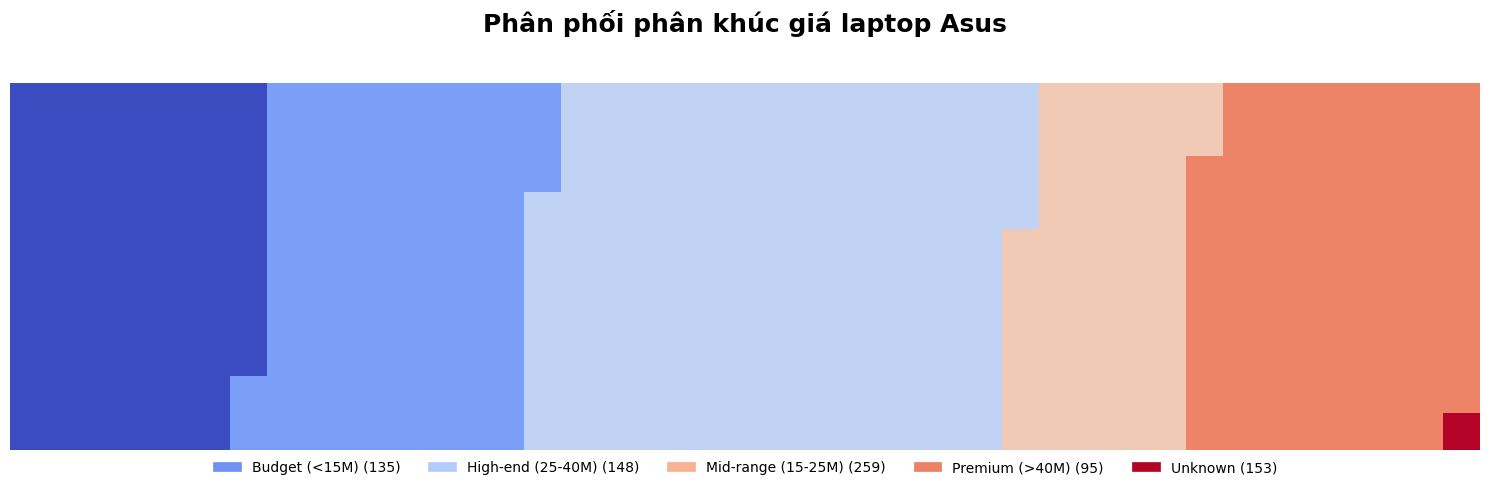

In [140]:
# Tạo figure
fig = plt.figure(figsize=(15, 8))

# Sử dụng colormap
colormap = plt.cm.coolwarm

# Vẽ waffle chart
ax = fig.add_subplot(111)
ax.matshow(waffle_chart, cmap=colormap)
ax.set_aspect('equal')
ax.axis('off')

# Tạo legend với tính toán cumulative sum để match colors
values_cumsum = np.cumsum(price_counts.values)
total_values = values_cumsum[-1]

legend_handles = []
for i, category in enumerate(price_counts.index):
    label_str = category + ' (' + str(price_counts.iloc[i]) + ')'
    color_val = colormap(float(values_cumsum[i]) / total_values)
    legend_handles.append(mpatches.Patch(color=color_val, label=label_str))

# Thêm legend
ax.legend(handles=legend_handles, 
          loc='lower center', 
          ncol=len(price_counts),
          bbox_to_anchor=(0.5, -0.1),
          framealpha=0)

ax.set_title('Phân phối phân khúc giá laptop Asus', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 2. Word Clouds (Biểu đồ đám mây từ)

Word Cloud là phương pháp trực quan hóa văn bản, trong đó các từ xuất hiện thường xuyên sẽ được hiển thị với kích thước lớn hơn.

### Bước 1: Tạo chuỗi văn bản từ tên laptop

Kết hợp tất cả tên laptop thành một chuỗi văn bản duy nhất để tạo Word Cloud.

In [141]:
# Kết hợp tất cả tên laptop thành một chuỗi
laptop_names = ' '.join(df_laptop['Name'].astype(str))
print(f"Tổng số ký tự: {len(laptop_names)}")
print(f"Mẫu văn bản: {laptop_names[:200]}...")

Tổng số ký tự: 31240
Mẫu văn bản: Laptop ASUS TUF Gaming F16 FX607VJ-RL034W Laptop ASUS VivoBook Go 14 E1404FA-NK177W Laptop ASUS Gaming Vivobook 16X K3605VC-RP431W Laptop ASUS Gaming V16 V3607VU-RP343W Laptop ASUS Vivobook 15 X1502VA...


### Bước 2: Tạo và hiển thị Word Cloud

Sử dụng thư viện WordCloud để tạo hình ảnh đám mây từ và hiển thị bằng Matplotlib.

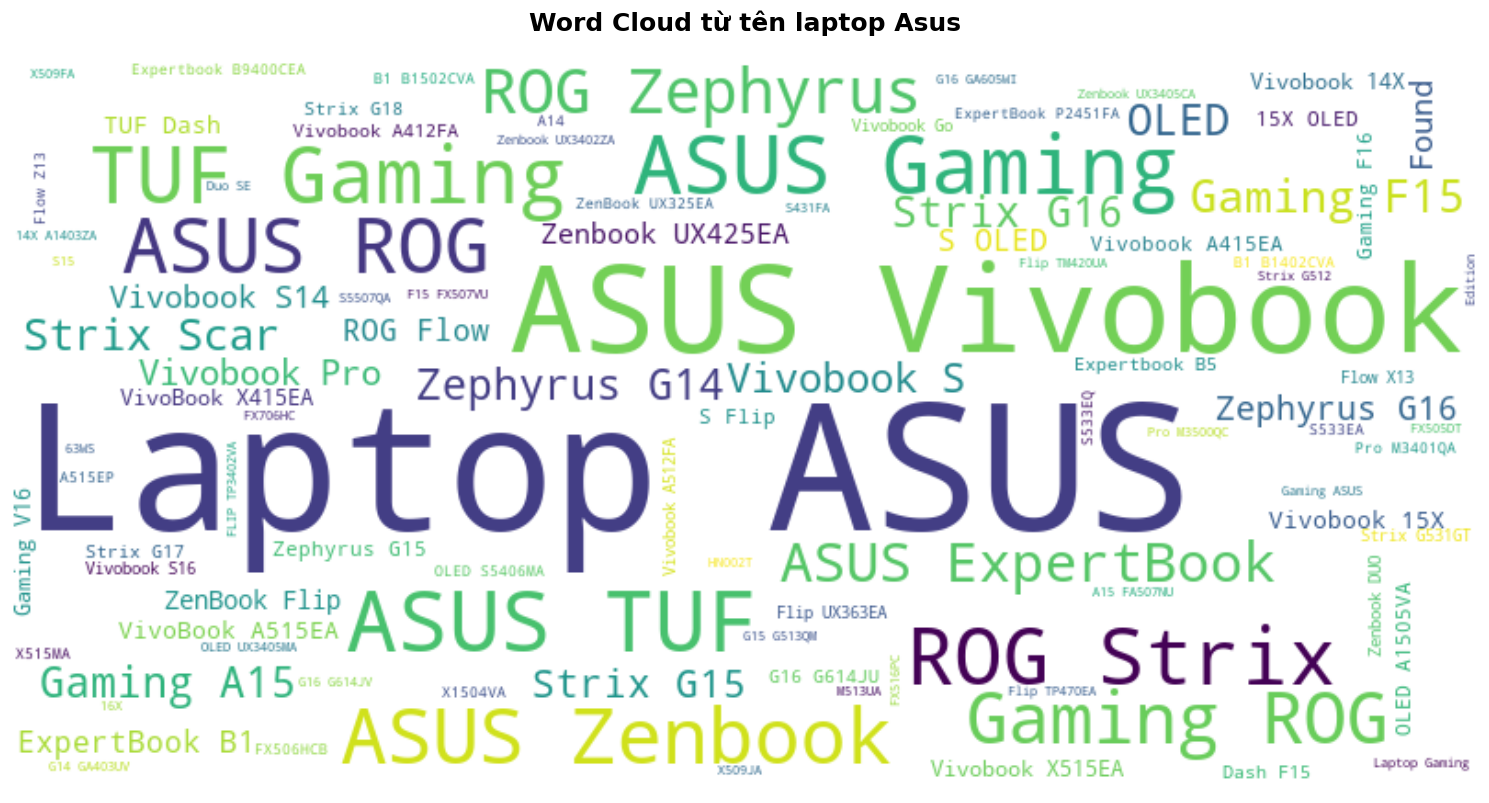

In [142]:
# Tạo Word Cloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      max_words=100,
                      colormap='viridis').generate(laptop_names)

# Vẽ Word Cloud
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud từ tên laptop Asus', fontsize=18, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## 3. Regression Plots (Biểu đồ hồi quy)

Regression plot kết hợp scatter plot với đường hồi quy tuyến tính và khoảng tin cậy, giúp hiểu mối quan hệ giữa các biến.

---
# Phần 3: Regression Plots với Seaborn

## Giới thiệu về Regression Plots

**Regression plot** kết hợp scatter plot với đường hồi quy tuyến tính, giúp ta thấy mối quan hệ giữa hai biến số và xu hướng của dữ liệu.

Seaborn cung cấp hàm `regplot()` để tạo regression plots một cách dễ dàng với các tính năng nâng cao như confidence intervals.

## Example 1: Mối quan hệ giữa RAM và Giá

### Ví dụ 1: Mối quan hệ giữa RAM và Giá

Phân tích xem dung lượng RAM có ảnh hưởng như thế nào đến giá laptop.

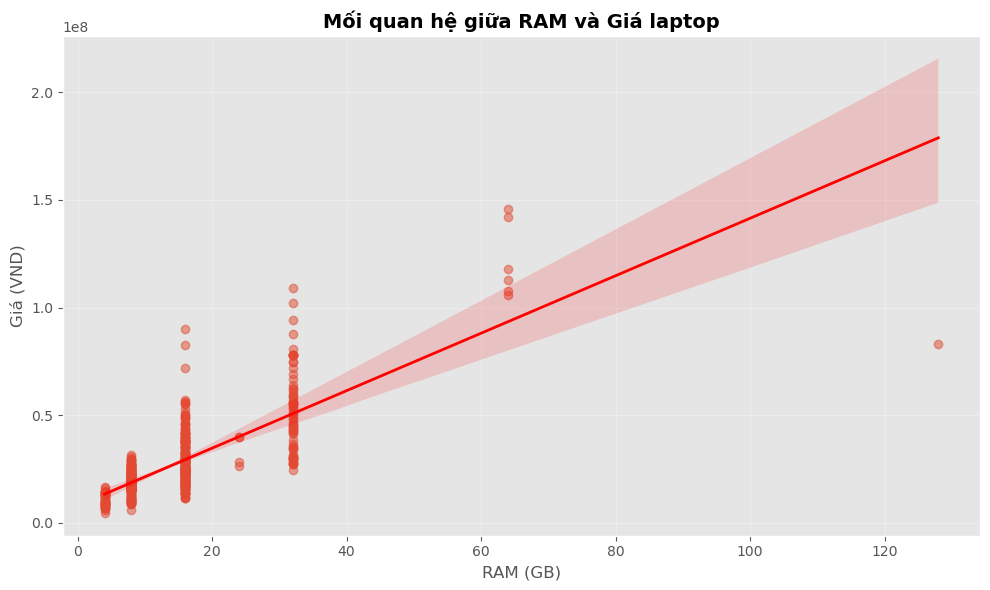

In [143]:
# Lọc dữ liệu không có giá trị NaN
df_plot1 = df_laptop[['RAM_GB', 'Price_VND']].dropna()

# Vẽ regression plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot1, x='RAM_GB', y='Price_VND', 
            scatter_kws={'alpha': 0.5}, 
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('Mối quan hệ giữa RAM và Giá laptop', fontsize=14, fontweight='bold')
plt.xlabel('RAM (GB)', fontsize=12)
plt.ylabel('Giá (VND)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Example 2: Mối quan hệ giữa Storage và Giá

### Ví dụ 2: Mối quan hệ giữa Storage và Giá

Phân tích xem dung lượng ổ cứng có ảnh hưởng như thế nào đến giá laptop.

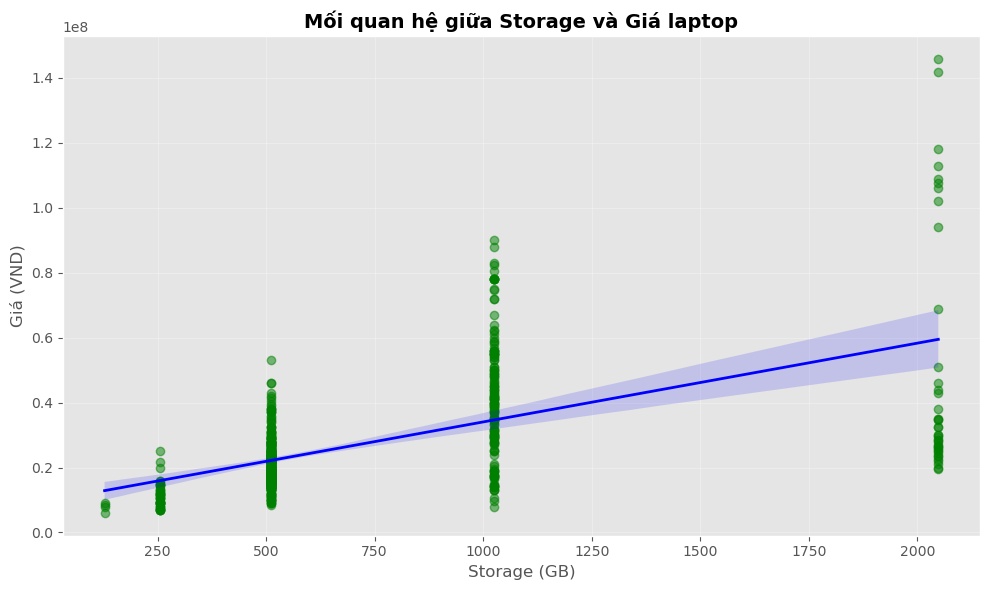

In [144]:
# Lọc dữ liệu không có giá trị NaN
df_plot2 = df_laptop[['Storage_GB', 'Price_VND']].dropna()

# Vẽ regression plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df_plot2, x='Storage_GB', y='Price_VND', 
            scatter_kws={'alpha': 0.5, 'color': 'green'}, 
            line_kws={'color': 'blue', 'linewidth': 2})
plt.title('Mối quan hệ giữa Storage và Giá laptop', fontsize=14, fontweight='bold')
plt.xlabel('Storage (GB)', fontsize=12)
plt.ylabel('Giá (VND)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Treemaps (Biểu đồ cây phân cấp)

Treemap hiển thị dữ liệu phân cấp dưới dạng các hình chữ nhật lồng nhau, kích thước tỷ lệ với giá trị.

---
# Phần 4: Treemaps

## Giới thiệu về Treemaps

**Treemap** là một dạng trực quan hóa hiển thị dữ liệu phân cấp bằng các hình chữ nhật lồng nhau. Mỗi nhánh của cấu trúc phân cấp được đại diện bởi một hình chữ nhật, sau đó được chia thành các hình chữ nhật nhỏ hơn đại diện cho các nhánh con.

## Ứng dụng của Treemaps

- **Phân tích kinh doanh**: Hiển thị doanh số theo danh mục sản phẩm
- **Tài chính**: Hiển thị hiệu suất danh mục đầu tư
- **IT**: Hiển thị cấu trúc file system
- **Analytics**: Hiển thị cấu trúc website và lưu lượng truy cập

## Example: Treemap cho Laptop theo CPU và GPU

### Ví dụ: Phân bố laptop theo CPU và GPU

Treemap 2 cấp hiển thị phân loại laptop theo CPU (cấp 1) và GPU (cấp 2), với kích thước tương ứng số lượng laptop.

In [145]:
# Chuẩn bị dữ liệu cho treemap
df_treemap = df_laptop.groupby(['CPU_Category', 'GPU_Category']).size().reset_index(name='Count')
df_treemap = df_treemap[df_treemap['Count'] > 0]  # Loại bỏ các nhóm rỗng

print("Dữ liệu treemap:")
print(df_treemap.head(10))
print(f"\nTổng số nhóm: {len(df_treemap)}")

# Hiển thị thống kê tổng quan
print("\n📊 Thống kê phân bố:")
print("-" * 50)
for cpu in df_treemap['CPU_Category'].unique():
    cpu_data = df_treemap[df_treemap['CPU_Category'] == cpu]
    total_count = cpu_data['Count'].sum()
    print(f"\n{cpu}: {total_count} laptop")
    for _, row in cpu_data.iterrows():
        print(f"  - {row['GPU_Category']}: {row['Count']} laptop")

# Tạo và hiển thị treemap với Plotly
print("\n" + "="*50)
print("🎨 Đang tạo Treemap...")
print("="*50)

fig = px.treemap(df_treemap, 
                 path=['CPU_Category', 'GPU_Category'], 
                 values='Count',
                 title='Phân bố laptop Asus theo CPU và GPU',
                 color='Count',
                 color_continuous_scale='RdYlGn')
fig.update_layout(width=1000, height=600)

# Hiển thị figure - sử dụng IPython display thay vì fig.show()
from IPython.display import display, HTML
display(HTML(fig.to_html()))

Dữ liệu treemap:
  CPU_Category GPU_Category  Count
0  AMD Ryzen 5   AMD Radeon     24
1  AMD Ryzen 5          GTX      8
2  AMD Ryzen 5     RTX 3050      1
3  AMD Ryzen 5     RTX 4050      2
4  AMD Ryzen 5     RTX 4060      1
5  AMD Ryzen 5    RTX Other      2
6  AMD Ryzen 5      Unknown      1
7  AMD Ryzen 7   AMD Radeon     17
8  AMD Ryzen 7          GTX     16
9  AMD Ryzen 7     RTX 3050     10

Tổng số nhóm: 54

📊 Thống kê phân bố:
--------------------------------------------------

AMD Ryzen 5: 39 laptop
  - AMD Radeon: 24 laptop
  - GTX: 8 laptop
  - RTX 3050: 1 laptop
  - RTX 4050: 2 laptop
  - RTX 4060: 1 laptop
  - RTX Other: 2 laptop
  - Unknown: 1 laptop

AMD Ryzen 7: 78 laptop
  - AMD Radeon: 17 laptop
  - GTX: 16 laptop
  - RTX 3050: 10 laptop
  - RTX 4050: 2 laptop
  - RTX 4060: 2 laptop
  - RTX Other: 31 laptop

AMD Ryzen 9: 34 laptop
  - AMD Radeon: 1 laptop
  - GTX: 1 laptop
  - RTX 4050: 1 laptop
  - RTX 4060: 5 laptop
  - RTX Other: 26 laptop

Intel Core i3: 54 lapt

## 5. Pivot Charts (Biểu đồ từ Pivot Table)

Pivot Chart kết hợp pivot table với biểu đồ để phân tích dữ liệu theo nhiều chiều.

---
# Phần 5: Pivot Charts

## Giới thiệu về Pivot Charts

**Pivot chart** là một công cụ mạnh mẽ để trực quan hóa và phân tích dữ liệu. Nó cho phép người dùng tổng kết và khám phá dataset lớn một cách động, tiết lộ insights và xu hướng.

## Ứng dụng của Pivot Charts

- **Business Intelligence**: Tổng kết dữ liệu kinh doanh phức tạp
- **Finance**: Phân tích dữ liệu tài chính và dự báo xu hướng
- **Marketing**: Phân tích hiệu suất chiến dịch
- **Operations**: Giám sát hiệu suất chuỗi cung ứng

## Example 1: Pivot Table - Giá trung bình theo CPU và RAM

### Ví dụ 1: Số lượng laptop theo CPU và Price Segment

Phân tích số lượng laptop trong mỗi phân khúc giá theo từng loại CPU.

Pivot Table: Số lượng laptop theo CPU và Price Segment
Price_Segment  Budget (<15M)  High-end (25-40M)  Mid-range (15-25M)  \
CPU_Category                                                          
AMD Ryzen 5                8                  2                  24   
AMD Ryzen 7                2                 28                  38   
AMD Ryzen 9                0                  8                   0   
Intel Core i3             40                  0                   0   
Intel Core i5             31                 13                  94   
Intel Core i7              3                 48                  28   
Intel Core i9              0                  1                   2   
Other                     51                 48                  73   
Unknown                    0                  0                   0   

Price_Segment  Premium (>40M)  Unknown  
CPU_Category                            
AMD Ryzen 5                 0        5  
AMD Ryzen 7                 7        3  

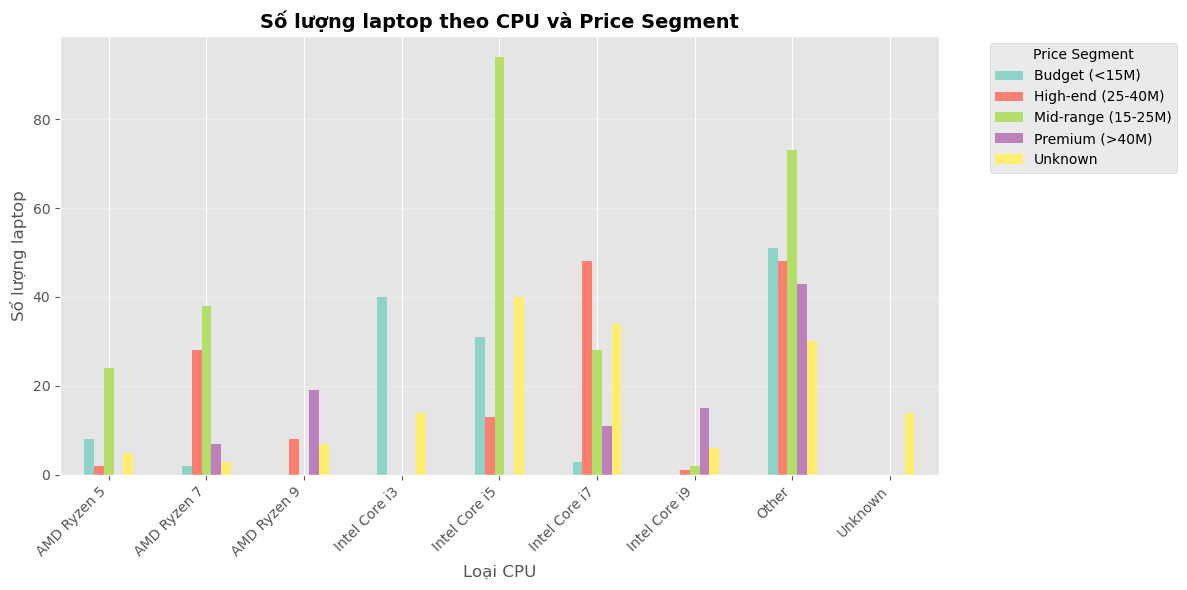

In [146]:
# Tạo pivot table
pivot1 = df_laptop.pivot_table(index='CPU_Category', 
                                columns='Price_Segment', 
                                values='Name', 
                                aggfunc='count', 
                                fill_value=0)

print("Pivot Table: Số lượng laptop theo CPU và Price Segment")
print(pivot1)

# Vẽ biểu đồ
pivot1.plot(kind='bar', figsize=(12, 6), colormap='Set3')
plt.title('Số lượng laptop theo CPU và Price Segment', fontsize=14, fontweight='bold')
plt.xlabel('Loại CPU', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)
plt.legend(title='Price Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Example 2: Pivot Chart - Trực quan hóa Pivot Table

### Ví dụ 2: Giá trung bình theo CPU và GPU

Phân tích giá trung bình laptop theo loại CPU và GPU.

Pivot Table: Giá trung bình (VND) theo CPU và GPU
GPU_Category     AMD Radeon         GTX  Intel Integrated         Other  \
CPU_Category                                                              
AMD Ryzen 5    1.592842e+07  19103750.0               NaN           NaN   
AMD Ryzen 7    2.015471e+07  24578000.0               NaN           NaN   
AMD Ryzen 9    4.199000e+07  33890000.0               NaN           NaN   
Intel Core i3           NaN         NaN      1.114650e+07           NaN   
Intel Core i5           NaN  20770000.0      1.800430e+07  1.913125e+07   
Intel Core i7           NaN  24430000.0      2.548917e+07  2.114000e+07   
Intel Core i9           NaN         NaN      2.144000e+07           NaN   
Other          2.313167e+07  22187000.0      2.046802e+07  2.325667e+07   

GPU_Category       RTX 3050    RTX 4050    RTX 4060    RTX 4070     RTX 4080  \
CPU_Category                                                                   
AMD Ryzen 5    1.699000e+07  23990000.0

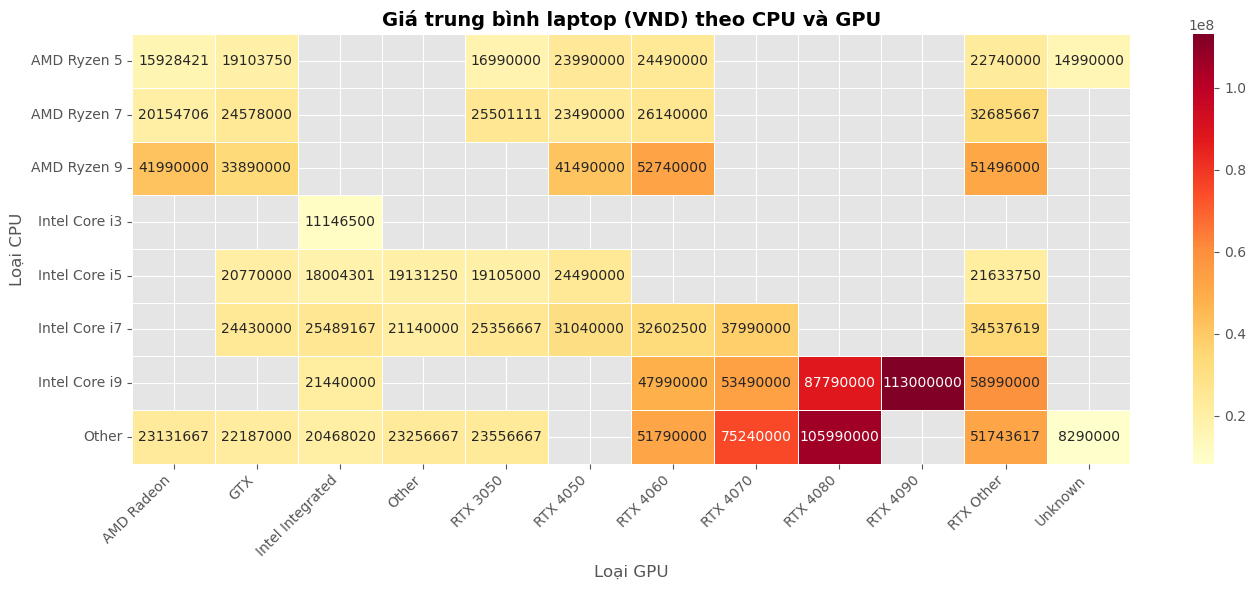

In [147]:
# Tạo pivot table
pivot2 = df_laptop.pivot_table(index='CPU_Category', 
                                columns='GPU_Category', 
                                values='Price_VND', 
                                aggfunc='mean')

print("Pivot Table: Giá trung bình (VND) theo CPU và GPU")
print(pivot2)

# Vẽ biểu đồ heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(pivot2, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Giá trung bình laptop (VND) theo CPU và GPU', fontsize=14, fontweight='bold')
plt.xlabel('Loại GPU', fontsize=12)
plt.ylabel('Loại CPU', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Example 3: Pivot Chart - Số lượng Laptop theo GPU và Phân khúc giá

### Ví dụ 3: Tổng số lượng laptop theo Price Segment và RAM

Phân tích phân bố laptop theo phân khúc giá và dung lượng RAM.

Pivot Table: Số lượng laptop theo Price Segment và RAM
RAM_GB              4    8    16   24   32   64   128
Price_Segment                                        
Budget (<15M)        46   47   16    0    0    0    0
High-end (25-40M)     0   27   89    4   22    0    0
Mid-range (15-25M)    2  138   88    0    1    0    0
Premium (>40M)        0    0   35    0   52    6    1
Unknown               6   26   27    0   19    5    0


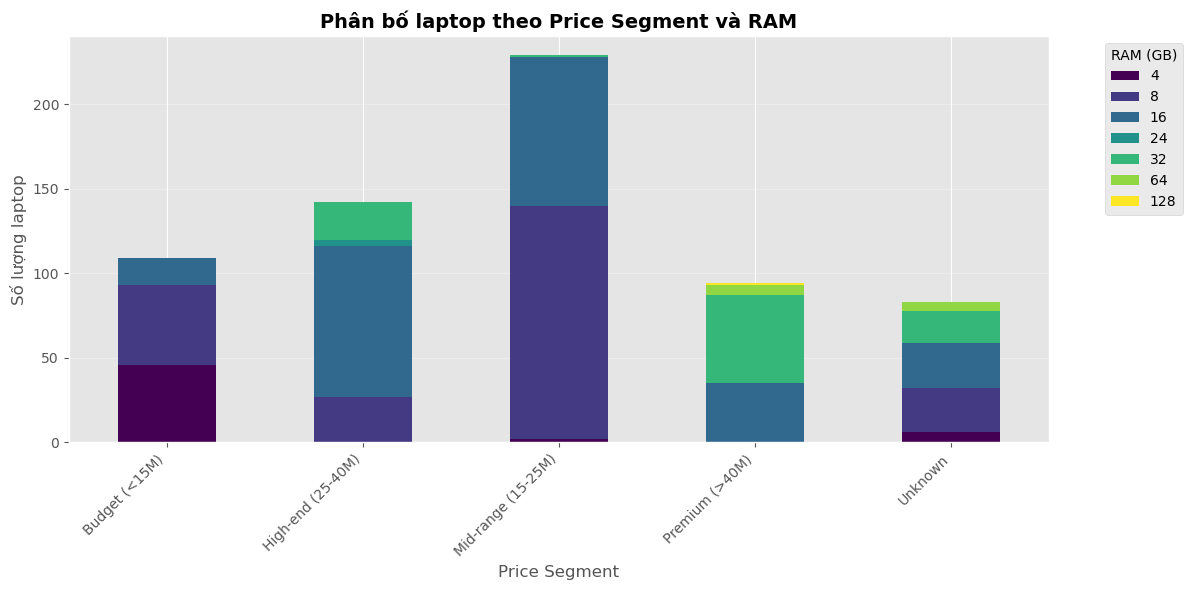

In [148]:
# Tạo pivot table
pivot3 = df_laptop.pivot_table(index='Price_Segment', 
                                columns='RAM_GB', 
                                values='Name', 
                                aggfunc='count', 
                                fill_value=0)

print("Pivot Table: Số lượng laptop theo Price Segment và RAM")
print(pivot3)

# Vẽ biểu đồ stacked bar
pivot3.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Phân bố laptop theo Price Segment và RAM', fontsize=14, fontweight='bold')
plt.xlabel('Price Segment', fontsize=12)
plt.ylabel('Số lượng laptop', fontsize=12)
plt.legend(title='RAM (GB)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Kết luận


1. **Waffle Charts**: Hiển thị tỷ lệ phần trăm theo phân khúc giá
2. **Word Clouds**: Trực quan hóa từ khóa phổ biến trong tên laptop
3. **Regression Plots**: Phân tích mối quan hệ giữa RAM/Storage và giá
4. **Treemaps**: Biểu diễn phân cấp CPU-GPU
5. **Pivot Charts**: Phân tích đa chiều với pivot table



---
# Kết luận


## Insights từ dữ liệu Laptop ASUS:

- **Phân khúc giá**: Phần lớn laptop tập trung ở phân khúc Mid-range và High-end
- **CPU phổ biến**: Intel Core i5 và Core i7 chiếm đa số
- **GPU**: Nhiều laptop sử dụng GPU tích hợp Intel, các dòng gaming có RTX
- **Tương quan**: RAM có mối tương quan mạnh với giá laptop
- **Từ khóa phổ biến**: Gaming, TUF, Vivobook, ROG xuất hiện nhiều trong tên
